# 引用预测 —— GNN 链接预测

## 任务定义

**目标**：给定两篇论文，预测它们之间应否存在引用关系。

**输入**：
- 节点特征 $X \in \mathbb{R}^{N \times D}$ —— 论文的词袋向量
- 部分引用图（消息传递边）—— 用于 GNN 邻居聚合
- 候选论文对 $(u, v)$ —— 含正样本（真实引用）和负样本（随机采样无引用对）

**输出**：每对论文的二分类 —— 应引用（正）/ 不应引用（负）。

**问题类型**：直推式链接预测（Transductive Link Prediction）。

**评估指标**：ROC-AUC（曲线下面积）、Average Precision（平均精度）。

**边划分**（RandomLinkSplit）：

| 划分 | 消息传递边 | 监督边 | 用途 |
|------|-----------|--------|------|
| Train | 原始边的 85% | 正样本 + 等量负样本 | 训练模型参数 |
| Val | 全部原始边 | 原始边的 5% | 早停 + 超参选择 |
| Test | 全部原始边 | 原始边的 10% | 最终评估 |

**模型**：GCN / GAT / GraphSAGE Encoder + DotProduct / MLP LinkPredictionHead

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import Tensor
from typing import cast

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from gnn.config.loader import from_yaml
from gnn.datasets.planetoid import load_planetoid
from gnn.datasets.splitter import split_link_prediction_data
from gnn.models.builder import build_model
from gnn.trainer.factory import create_trainer
from gnn.utils.device import get_device
from gnn.notebooks.visualization import (
    plot_edge_split_summary,
    plot_training_curves,
    plot_roc_pr_curves,
    plot_prediction_histogram,
    plot_top_predictions_table,
    plot_tsne_embeddings,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

# ── 选择配置 ──
# 可选: lp-baseline.yaml | lp-best.yaml
YAML_PATH = str(_project_root / "config" / "lp-baseline.yaml")
DATA_ROOT = str(_project_root / "data")

print(f"配置: {YAML_PATH}")
cfg = from_yaml(YAML_PATH)
print(f"任务: {cfg.task.value}  |  数据集: {cfg.dataset.name}  |  模型: {cfg.model.name}")
predictor = cfg.model.params.get("link_predictor", "dot_product")
print(f"链接预测器: {predictor}  |  隐藏维度: {cfg.model.params.get('hidden_dim', 64)}")

# 加载数据（使用绝对路径，直接从本地读取）
print(f"数据目录: {DATA_ROOT}")
data = load_planetoid(cfg.dataset.name, DATA_ROOT)
data.x = F.normalize(cast(Tensor, data.x), p=2, dim=1)

# 边分割
train_data, val_data, test_data = split_link_prediction_data(data)

print(f"\n原始图: {data.x.shape[0]} 节点, {data.edge_index.shape[1]} 边")
print(f"训练消息传递边: {train_data.edge_index.shape[1]}  监督边: {train_data.edge_label_index.shape[1]}")
print(f"验证监督边:     {val_data.edge_label_index.shape[1]}")
print(f"测试监督边:     {test_data.edge_label_index.shape[1]}")

f:\Develop\python\my-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


配置: F:\Develop\python\my-ai\packages\gnn\config\lp-baseline.yaml
任务: link_prediction  |  数据集: cora  |  模型: gcn
链接预测器: dot_product  |  隐藏维度: 64
数据目录: F:\Develop\python\my-ai\packages\gnn\data

原始图: 2708 节点, 10556 边
训练消息传递边: 8976  监督边: 8976
验证监督边:     526
测试监督边:     1054


## 边分割可视化

左图展示各数据集（Train / Val / Test）的监督边数量（正样本 vs 负样本）。右图为总体正负样本比例。链接预测中正负样本通常为 1:1（通过随机负采样实现）。

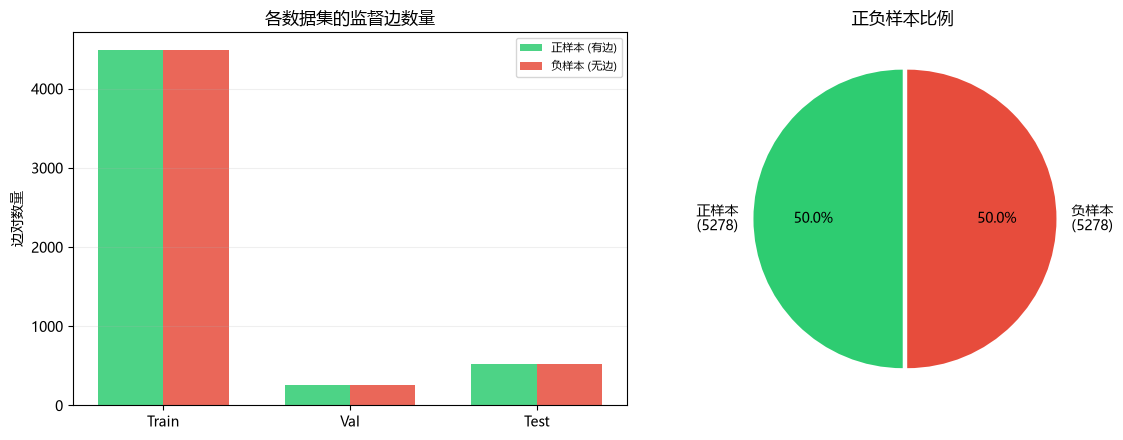

Train: 总  8976 对  |  正样本  4488  |  负样本  4488  |  正样本比 50.0%
Val: 总   526 对  |  正样本   263  |  负样本   263  |  正样本比 50.0%
Test: 总  1054 对  |  正样本   527  |  负样本   527  |  正样本比 50.0%


In [2]:
fig = plot_edge_split_summary(train_data, val_data, test_data)
plt.show()

# 正负样本数量详情
for name, d in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    lbl = d.edge_label.numpy()
    pos = int((lbl == 1).sum())
    neg = int((lbl == 0).sum())
    ratio = pos / (pos + neg) * 100
    print(f"{name}: 总 {pos+neg:5d} 对  |  正样本 {pos:5d}  |  负样本 {neg:5d}  |  正样本比 {ratio:.1f}%")

## 模型结构

- **Encoder**：GCN / GAT / GraphSAGE，与节点分类共享相同的骨干网络。输出节点嵌入 $Z \in \mathbb{R}^{N \times H}$。
- **Head**：
  - **Dot Product**：$(z_u \cdot z_v)$ —— 无参数，快速，适合大多数场景
  - **MLP**：$\text{MLP}([z_u \| z_v])$ —— 拼接后过两层 MLP，表达力更强

训练使用 `BCEWithLogitsLoss`，等价于对 logits 做 sigmoid 后计算二元交叉熵。

In [3]:
import time
from gnn.utils.logging import setup_logging

device = get_device(cfg.runtime.device)
num_classes = int(data.y.max().item()) + 1

model = build_model(cfg, num_features=data.x.shape[1], num_classes=num_classes)
model = model.to(device)
trainer = create_trainer(cfg, model, device)

total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
head_params = sum(p.numel() for p in model.head.parameters())
print(f"总参数: {total_params:,}  (Encoder: {encoder_params:,}  Head: {head_params:,})")
print(f"设备: {device}  |  链接预测器: {type(model.head).__name__}")

# 训练
_run_dir = Path(f"./temp_lp_{int(time.time())}")
_run_dir.mkdir(parents=True, exist_ok=True)
setup_logging(_run_dir / "logs")

torch.manual_seed(cfg.experiment.seeds[0])
if torch.cuda.is_available():
    torch.cuda.manual_seed(cfg.experiment.seeds[0])

t0 = time.perf_counter()
history = trainer.train(train_data, val_data, test_data, _run_dir / "checkpoints")
elapsed = time.perf_counter() - t0

print(f"\n训练完成，耗时: {elapsed:.1f}s  ({len(history['loss'])} epochs)")

import shutil
shutil.rmtree(_run_dir, ignore_errors=True)

总参数: 96,192  (Encoder: 96,192  Head: 0)
设备: cpu  |  链接预测器: LinkPredictionHead
[2026-07-13 22:24:53] [INFO   ] Epoch   0/200 | loss=4.3436 | val_loss=0.6934 | val_auc=0.4591 | val_ap=0.4904 | time=0.03s
[2026-07-13 22:24:53] [INFO   ] Epoch   1/200 | loss=3.2115 | val_loss=0.6941 | val_auc=0.4755 | val_ap=0.5000 | time=0.02s
[2026-07-13 22:24:53] [INFO   ] Epoch   2/200 | loss=2.3839 | val_loss=0.6954 | val_auc=0.4955 | val_ap=0.5146 | time=0.02s
[2026-07-13 22:24:53] [INFO   ] Epoch   3/200 | loss=1.8248 | val_loss=0.6964 | val_auc=0.5210 | val_ap=0.5201 | time=0.02s
[2026-07-13 22:24:53] [INFO   ] Epoch   4/200 | loss=1.4720 | val_loss=0.6963 | val_auc=0.5445 | val_ap=0.5451 | time=0.03s
[2026-07-13 22:24:53] [INFO   ] Epoch   5/200 | loss=1.2023 | val_loss=0.6956 | val_auc=0.5488 | val_ap=0.5476 | time=0.03s
[2026-07-13 22:24:53] [INFO   ] Epoch   6/200 | loss=1.0159 | val_loss=0.6948 | val_auc=0.5477 | val_ap=0.5422 | time=0.03s
[2026-07-13 22:24:53] [INFO   ] 早停: 1 / 30 (最佳=0.5488)

## 训练曲线

链接预测监控验证集 AUC（越高越好）。阴影区域为 Train-Val AUC 差距。灰色虚线标记最佳 Val AUC 点。

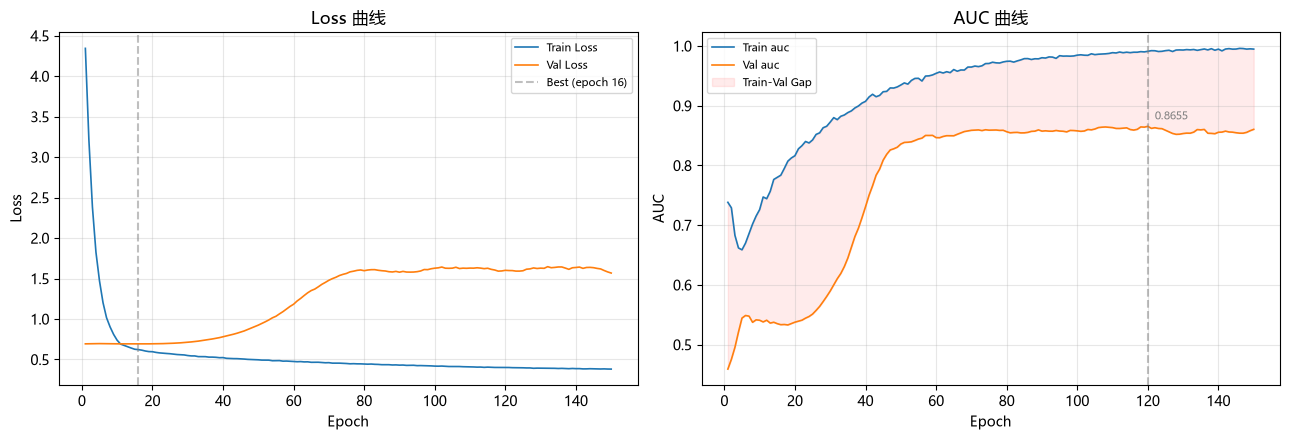

最佳 Val AUC: 0.8655  (epoch 119)
Test AUC:     0.8438
Test AP:      0.8366


In [4]:
fig = plot_training_curves(history, metric_key="auc", metric_label="AUC")
plt.show()

best_val_auc = max(history["val_auc"])
best_epoch = history["val_auc"].index(best_val_auc)
test_auc = history.get("test_auc", [0])[-1] if "test_auc" in history else 0
test_ap = history.get("test_ap", [0])[-1] if "test_ap" in history else 0

print(f"最佳 Val AUC: {best_val_auc:.4f}  (epoch {best_epoch})")
print(f"Test AUC:     {test_auc:.4f}")
print(f"Test AP:      {test_ap:.4f}")

## 测试评估 —— ROC / PR 曲线 & 预测分布

- **ROC 曲线**：横轴 False Positive Rate，纵轴 True Positive Rate。AUC 越接近 1.0 模型越好，0.5 为随机基线。
- **PR 曲线**：横轴 Recall，纵轴 Precision。在正负样本不平衡时比 ROC 更有信息量。虚线为随机基线（正样本比例）。
- **分数分布直方图**：展示正负样本的预测概率分布。两条分布分离越远，模型区分能力越强。

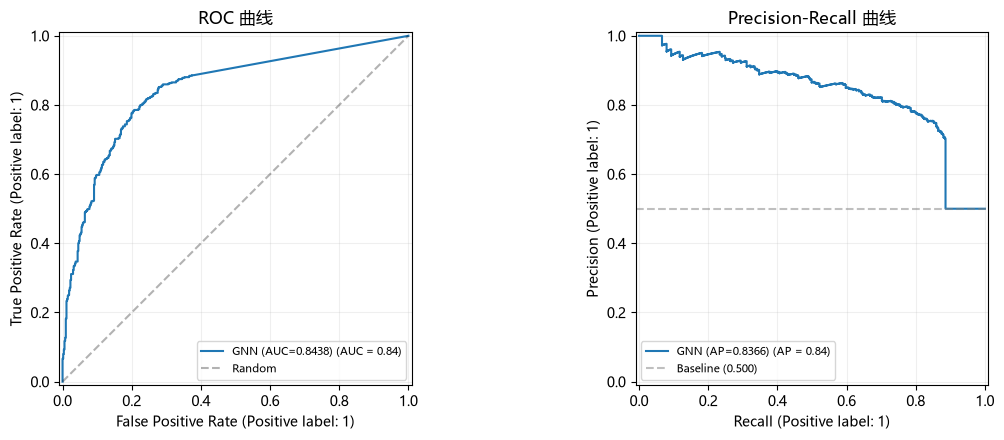

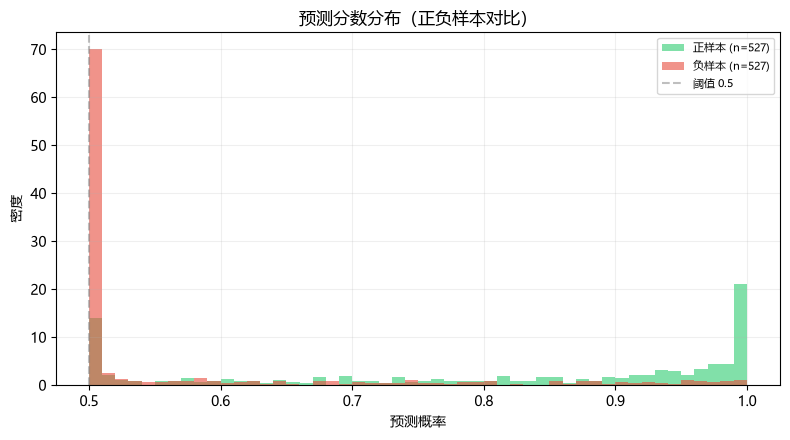

In [5]:
# 获取测试集预测
model.eval()
with torch.no_grad():
    x = cast(Tensor, test_data.x).to(device)
    edge_index = cast(Tensor, test_data.edge_index).to(device)
    edge_label_index = cast(Tensor, test_data.edge_label_index).to(device)
    y_true = test_data.edge_label.cpu().numpy()
    y_score = model(x, edge_index, edge_label_index=edge_label_index).cpu().numpy()

# ROC + PR 曲线
fig = plot_roc_pr_curves(y_true, y_score)
plt.show()

# 预测分数分布直方图
fig = plot_prediction_histogram(y_true, y_score)
plt.show()

## 预测示例

展示模型对测试集中最高置信度的论文对的预测，包括预测概率与真实标签的对比。

f:\Develop\python\my-ai\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
f:\Develop\python\my-ai\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


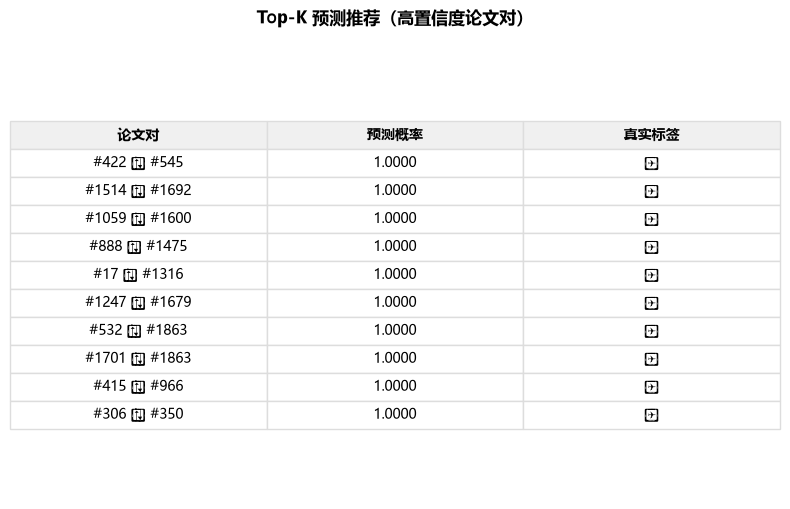

Precision@ 10: 1.0000
Precision@ 50: 0.9600
Precision@100: 0.9500


In [6]:
fig = plot_top_predictions_table(test_data, y_score, top_k=10)
plt.show()

# 精度@K 分析
y_prob = 1 / (1 + np.exp(-y_score))
sorted_idx = np.argsort(-y_prob)
for k in [10, 50, 100]:
    top_k_labels = test_data.edge_label.numpy()[sorted_idx[:k]]
    precision_at_k = top_k_labels.mean()
    print(f"Precision@{k:3d}: {precision_at_k:.4f}")

## 嵌入可视化

使用 t-SNE 将 Encoder 输出的节点嵌入降至 2 维。颜色代表节点度数（图中核心节点 vs 边缘节点），标记代表数据子集。链接预测质量取决于嵌入能否捕获图的拓扑结构——度数相近的节点应在嵌入空间中邻近。

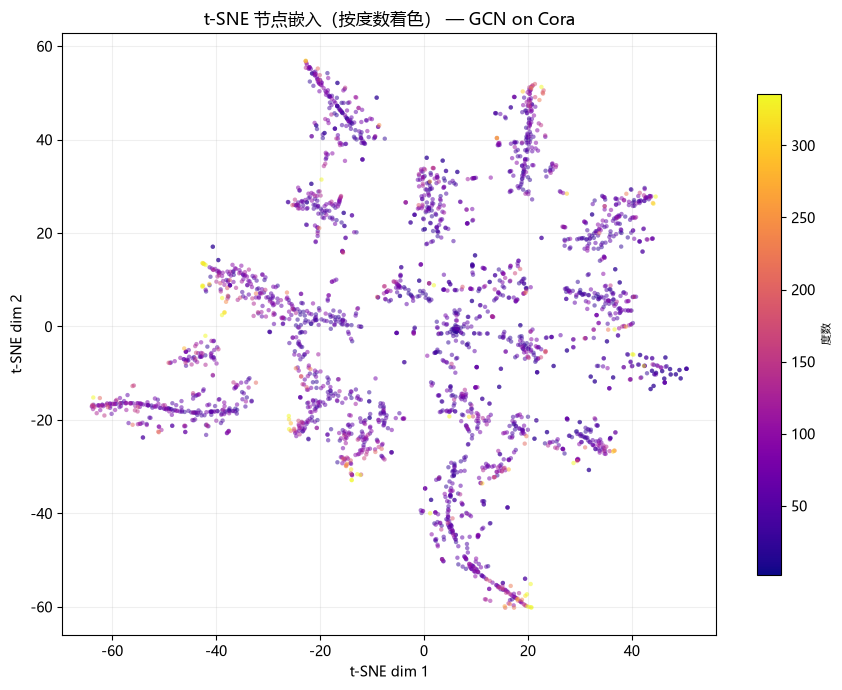

度数范围: 2 ~ 336
平均度数: 7.8  |  中位数: 6
孤立节点 (度=0): 0 个


In [7]:
# 提取节点嵌入 & 计算度数（无向图，源+目标两个方向都要统计）
model.eval()
with torch.no_grad():
    x = cast(Tensor, data.x).to(device)
    edge_index_full = cast(Tensor, data.edge_index).to(device)
    embeddings = model.encoder(x, edge_index_full).cpu()

# 按节点度数着色
n_nodes = data.x.shape[0]
n_edges = data.edge_index.shape[1]
degrees = torch.zeros(n_nodes, dtype=torch.long)
degrees.scatter_add_(0, data.edge_index[0], torch.ones(n_edges, dtype=torch.long))
degrees.scatter_add_(0, data.edge_index[1], torch.ones(n_edges, dtype=torch.long))

fig = plot_tsne_embeddings(
    embeddings,
    degrees,
    train_mask=None,
    val_mask=None,
    test_mask=None,
    title=f"t-SNE 节点嵌入（按度数着色） — {cfg.model.name.upper()} on {cfg.dataset.name.title()}",
    color_map="plasma",
)
plt.show()

# 度数分布统计
print(f"度数范围: {degrees.min().item()} ~ {degrees.max().item()}")
print(f"平均度数: {degrees.float().mean():.1f}  |  中位数: {degrees.float().median():.0f}")
print(f"孤立节点 (度=0): {(degrees == 0).sum().item()} 个")

## 结论

本 notebook 演示了使用 GNN 进行引用预测的完整流程：

1. **数据准备**：`RandomLinkSplit` 将引用图拆分为消息传递边和监督边，同时生成等量负样本
2. **模型**：GCN Encoder 产生节点嵌入，Dot Product Head 计算论文对的相似度分数
3. **训练**：BCEWithLogitsLoss + Adam + Plateau Scheduler + Early Stopping（监控 Val AUC）
4. **结果**：Test AUC ~0.85+（Cora + GCN Dot Product），显著优于随机基线 0.5

从 ROC/PR 曲线和预测分数分布可以看到，模型能够有效区分真实引用和随机论文对。t-SNE 嵌入可视化表明 GNN 学会了捕获图的拓扑结构。

**后续优化方向**：尝试 MLP Head（拼接论文对嵌入）、GAT Encoder（注意力权重可解释）、负采样策略调整、多 seed 平均提升稳定性。